In [39]:
from pathlib import Path
import pandas as pd
import numpy as np
import duckdb
import matplotlib.pyplot as plt
# -----------------------------
# Paths
# -----------------------------

PROJECT_ROOT = Path("..")

RAW_DIR = PROJECT_ROOT / "data" / "raw" / "ahccd"
INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
DB_PATH = PROJECT_ROOT / "database" / "climate.duckdb"

CSV_PATH = RAW_DIR / "ahccd.csv"
METADATA_PATH = RAW_DIR / "metadata.txt"

# -----------------------------
# Verify files
# -----------------------------

print("CSV exists:", CSV_PATH.exists())
print("Metadata exists:", METADATA_PATH.exists())

# -----------------------------
# Load AHCCD data
# -----------------------------

df = pd.read_csv(CSV_PATH)

print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

# -----------------------------
# Basic inspection
# -----------------------------

print("\nMissing values:")
display(df.isna().sum())

print("\nDataset info:")
df.info()

# -----------------------------
# DuckDB connection
# -----------------------------

con = duckdb.connect(str(DB_PATH))

print("\nDuckDB version:")
print(con.execute("SELECT version()").fetchone()[0])

CSV exists: True
Metadata exists: True

Shape:
(25809, 13)

Columns:
['time', 'station', 'station_name', 'lon', 'lat', 'elev', 'prov', 'tas', 'tas_flag', 'tasmax', 'tasmax_flag', 'tasmin', 'tasmin_flag']

Data types:
time                str
station           int64
station_name        str
lon             float64
lat             float64
elev            float64
prov                str
tas             float64
tas_flag            str
tasmax          float64
tasmax_flag         str
tasmin          float64
tasmin_flag         str
dtype: object

First 5 rows:


,time,station,station_name,lon,lat,elev,prov,tas,tas_flag,tasmax,tasmax_flag,tasmin,tasmin_flag
0,1953-05-04,6158359,TORONTO CITY CENTRE,-79.4,43.63,77.0,ONT,12.5,NaN,14.4,NaN,10.6,NaN
1,1953-05-05,6158359,TORONTO CITY CENTRE,-79.4,43.63,77.0,ONT,11.4,NaN,15.6,NaN,7.2,NaN
2,1953-05-06,6158359,TORONTO CITY CENTRE,-79.4,43.63,77.0,ONT,12.3,NaN,16.7,NaN,7.8,NaN
3,1953-05-07,6158359,TORONTO CITY CENTRE,-79.4,43.63,77.0,ONT,13.3,NaN,18.3,NaN,8.3,NaN
4,1953-05-08,6158359,TORONTO CITY CENTRE,-79.4,43.63,77.0,ONT,12.8,NaN,17.2,NaN,8.3,NaN



Missing values:


time                0
station             0
station_name        0
lon                 0
lat                 0
elev                0
prov                0
tas               136
tas_flag        25624
tasmax            130
tasmax_flag     25632
tasmin            131
tasmin_flag     25584
dtype: int64


Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 25809 entries, 0 to 25808
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   time          25809 non-null  str    
 1   station       25809 non-null  int64  
 2   station_name  25809 non-null  str    
 3   lon           25809 non-null  float64
 4   lat           25809 non-null  float64
 5   elev          25809 non-null  float64
 6   prov          25809 non-null  str    
 7   tas           25673 non-null  float64
 8   tas_flag      185 non-null    str    
 9   tasmax        25679 non-null  float64
 10  tasmax_flag   177 non-null    str    
 11  tasmin        25678 non-null  float64
 12  tasmin_flag   225 non-null    str    
dtypes: float64(6), int64(1), str(6)
memory usage: 3.4 MB

DuckDB version:
v1.5.5


In [21]:
print("First rows:")
display(df.head())

print("\nLast rows:")
display(df.tail())

print("\nNumber of rows:", len(df))
print("Number of columns:", len(df.columns))

print("\nColumn names:")
for i, col in enumerate(df.columns):
    print(i, col)

First rows:


,time,station,station_name,lon,lat,elev,prov,tas,tas_flag,tasmax,tasmax_flag,tasmin,tasmin_flag
0,1953-05-04,6158359,TORONTO CITY CENTRE,-79.4,43.63,77.0,ONT,12.5,NaN,14.4,NaN,10.6,NaN
1,1953-05-05,6158359,TORONTO CITY CENTRE,-79.4,43.63,77.0,ONT,11.4,NaN,15.6,NaN,7.2,NaN
2,1953-05-06,6158359,TORONTO CITY CENTRE,-79.4,43.63,77.0,ONT,12.3,NaN,16.7,NaN,7.8,NaN
3,1953-05-07,6158359,TORONTO CITY CENTRE,-79.4,43.63,77.0,ONT,13.3,NaN,18.3,NaN,8.3,NaN
4,1953-05-08,6158359,TORONTO CITY CENTRE,-79.4,43.63,77.0,ONT,12.8,NaN,17.2,NaN,8.3,NaN



Last rows:


,time,station,station_name,lon,lat,elev,prov,tas,tas_flag,tasmax,tasmax_flag,tasmin,tasmin_flag
25804,2023-12-27,6158359,TORONTO CITY CENTRE,-79.4,43.63,77.0,ONT,7.3,NaN,8.1,NaN,6.4,NaN
25805,2023-12-28,6158359,TORONTO CITY CENTRE,-79.4,43.63,77.0,ONT,6.2,NaN,7.5,NaN,4.9,NaN
25806,2023-12-29,6158359,TORONTO CITY CENTRE,-79.4,43.63,77.0,ONT,4.0,NaN,5.4,NaN,2.5,NaN
25807,2023-12-30,6158359,TORONTO CITY CENTRE,-79.4,43.63,77.0,ONT,1.3,NaN,2.7,NaN,-0.3,NaN
25808,2023-12-31,6158359,TORONTO CITY CENTRE,-79.4,43.63,77.0,ONT,0.5,NaN,2.0,NaN,-1.0,NaN



Number of rows: 25809
Number of columns: 13

Column names:
0 time
1 station
2 station_name
3 lon
4 lat
5 elev
6 prov
7 tas
8 tas_flag
9 tasmax
10 tasmax_flag
11 tasmin
12 tasmin_flag


In [22]:
with open(METADATA_PATH, "r", encoding="utf-8") as f:
    metadata = f.read()

print(metadata[:5000])

# Global attributes
# 
# title:: Third Generation of Homogenized Daily Temperature for Canada Update to December 2023
# history:: 2024-06-11 : Convert from original format to NetCDF
# type:: station_obs
# institute:: Environment and Climate Change Canada
# institute_id:: ECCC
# dataset_id:: AHCCD_gen3_day_temperature
# frequency:: day
# licence_type:: permissive
# licence:: https:/open.canada.ca/en/open-government-licence-canada
# citation:: Vincent, L.A., M.M. Hartwell and X.L. Wang, 2020: A Third Generation of Homogenized Temperature for Trend Analysis and Monitoring Changes in Canada’s Climate. Atmosphere-Ocean. https://doi.org/10.1080/07055900.2020.1765728 
#
# Coordinates
#   time
#   station
#     long_name:: station identification number
#   station_name
#     long_name:: station name
#
# Data variables
#   tas
#     _FillValue:: nan
#     units:: degC
#     standard_name:: air_temperature
#     long_name:: Near-Surface Daily Mean Air Temperature
#     comment:: ECCC Third Gener

In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25809 entries, 0 to 25808
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   time          25809 non-null  str    
 1   station       25809 non-null  int64  
 2   station_name  25809 non-null  str    
 3   lon           25809 non-null  float64
 4   lat           25809 non-null  float64
 5   elev          25809 non-null  float64
 6   prov          25809 non-null  str    
 7   tas           25673 non-null  float64
 8   tas_flag      185 non-null    str    
 9   tasmax        25679 non-null  float64
 10  tasmax_flag   177 non-null    str    
 11  tasmin        25678 non-null  float64
 12  tasmin_flag   225 non-null    str    
dtypes: float64(6), int64(1), str(6)
memory usage: 3.4 MB


In [24]:
pip install xarray netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 6.5 MB/s  0:00:006.2 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.8/22.8 MB 10.5 MB/s  0:00:02 10.6 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [xarray]━━━━━━━━━━━ 2/3 [xarray]
Note: you may need to restart the kernel to use updated packages.


In [26]:
from pathlib import Path
import pandas as pd

RAW_DIR = Path("../data/raw/ahccd")

CSV_PATH = RAW_DIR / "ahccd.csv"

df = pd.read_csv(CSV_PATH)

print(df.shape)
print(df.columns.tolist())
display(df.head())

(25809, 13)
['time', 'station', 'station_name', 'lon', 'lat', 'elev', 'prov', 'tas', 'tas_flag', 'tasmax', 'tasmax_flag', 'tasmin', 'tasmin_flag']


,time,station,station_name,lon,lat,elev,prov,tas,tas_flag,tasmax,tasmax_flag,tasmin,tasmin_flag
0,1953-05-04,6158359,TORONTO CITY CENTRE,-79.4,43.63,77.0,ONT,12.5,NaN,14.4,NaN,10.6,NaN
1,1953-05-05,6158359,TORONTO CITY CENTRE,-79.4,43.63,77.0,ONT,11.4,NaN,15.6,NaN,7.2,NaN
2,1953-05-06,6158359,TORONTO CITY CENTRE,-79.4,43.63,77.0,ONT,12.3,NaN,16.7,NaN,7.8,NaN
3,1953-05-07,6158359,TORONTO CITY CENTRE,-79.4,43.63,77.0,ONT,13.3,NaN,18.3,NaN,8.3,NaN
4,1953-05-08,6158359,TORONTO CITY CENTRE,-79.4,43.63,77.0,ONT,12.8,NaN,17.2,NaN,8.3,NaN


In [27]:
from pathlib import Path
import pandas as pd
import xarray as xr

RAW_DIR = Path("../data/raw/ahccd")

files = [
    f for f in RAW_DIR.iterdir()
    if f.is_file() and not f.name.startswith(".")
]

for file in files:
    print(file.name)

for file in files:

    if file.suffix.lower() == ".csv":
        print(f"Loading CSV: {file.name}")

        df = pd.read_csv(file)

        print(df.shape)
        display(df.head())

    elif file.suffix.lower() in [".nc", ".netcdf"]:
        print(f"Loading NetCDF: {file.name}")

        ds = xr.open_dataset(
            file,
            engine="netcdf4"
        )

        print(ds)

metadata.txt
ahccd.csv
Loading CSV: ahccd.csv
(25809, 13)


,time,station,station_name,lon,lat,elev,prov,tas,tas_flag,tasmax,tasmax_flag,tasmin,tasmin_flag
0,1953-05-04,6158359,TORONTO CITY CENTRE,-79.4,43.63,77.0,ONT,12.5,NaN,14.4,NaN,10.6,NaN
1,1953-05-05,6158359,TORONTO CITY CENTRE,-79.4,43.63,77.0,ONT,11.4,NaN,15.6,NaN,7.2,NaN
2,1953-05-06,6158359,TORONTO CITY CENTRE,-79.4,43.63,77.0,ONT,12.3,NaN,16.7,NaN,7.8,NaN
3,1953-05-07,6158359,TORONTO CITY CENTRE,-79.4,43.63,77.0,ONT,13.3,NaN,18.3,NaN,8.3,NaN
4,1953-05-08,6158359,TORONTO CITY CENTRE,-79.4,43.63,77.0,ONT,12.8,NaN,17.2,NaN,8.3,NaN


# First data-quality questions

In [28]:
# Earliest date?
# Latest date?
# Number of observations?
# Station name?
# Latitude/longitude?
# Available variables?
# Missing Tmax?
# Missing Tmin?
# Missing Tmean?
# Duplicate dates?

In [29]:
print(df.shape)
print(df.columns)
print(df.isna().sum())

(25809, 13)
Index(['time', 'station', 'station_name', 'lon', 'lat', 'elev', 'prov', 'tas',
       'tas_flag', 'tasmax', 'tasmax_flag', 'tasmin', 'tasmin_flag'],
      dtype='str')
time                0
station             0
station_name        0
lon                 0
lat                 0
elev                0
prov                0
tas               136
tas_flag        25624
tasmax            130
tasmax_flag     25632
tasmin            131
tasmin_flag     25584
dtype: int64


In [30]:
with open("../data/raw/ahccd/metadata.txt", "r") as f:
    metadata = f.read()

print(metadata)

# Global attributes
# 
# title:: Third Generation of Homogenized Daily Temperature for Canada Update to December 2023
# history:: 2024-06-11 : Convert from original format to NetCDF
# type:: station_obs
# institute:: Environment and Climate Change Canada
# institute_id:: ECCC
# dataset_id:: AHCCD_gen3_day_temperature
# frequency:: day
# licence_type:: permissive
# licence:: https:/open.canada.ca/en/open-government-licence-canada
# citation:: Vincent, L.A., M.M. Hartwell and X.L. Wang, 2020: A Third Generation of Homogenized Temperature for Trend Analysis and Monitoring Changes in Canada’s Climate. Atmosphere-Ocean. https://doi.org/10.1080/07055900.2020.1765728 
#
# Coordinates
#   time
#   station
#     long_name:: station identification number
#   station_name
#     long_name:: station name
#
# Data variables
#   tas
#     _FillValue:: nan
#     units:: degC
#     standard_name:: air_temperature
#     long_name:: Near-Surface Daily Mean Air Temperature
#     comment:: ECCC Third Gener

In [31]:
for col in ["tas_flag", "tasmax_flag", "tasmin_flag"]:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False))


tas_flag
tas_flag
NaN    25624
E        185
Name: count, dtype: int64

tasmax_flag
tasmax_flag
NaN    25632
e        104
E         73
Name: count, dtype: int64

tasmin_flag
tasmin_flag
NaN    25584
E        168
e         57
Name: count, dtype: int64


In [32]:
temp_cols = ["tas", "tasmax", "tasmin"]
flag_cols = ["tas_flag", "tasmax_flag", "tasmin_flag"]

# Temperature missingness
for col in temp_cols:
    missing = df[col].isna().sum()
    pct = df[col].isna().mean() * 100

    print(
        f"{col}: {missing} missing "
        f"({pct:.3f}%)"
    )

tas: 136 missing (0.527%)
tasmax: 130 missing (0.504%)
tasmin: 131 missing (0.508%)


In [33]:
for temp_col, flag_col in zip(temp_cols, flag_cols):

    print(f"\n--- {temp_col} / {flag_col} ---")

    display(
        df.loc[
            df[flag_col].notna(),
            ["time", temp_col, flag_col]
        ].head(20)
    )


--- tas / tas_flag ---


,time,tas,tas_flag
8671,1977-01-29,-18.1,E
8672,1977-01-30,-13.2,E
12456,1987-06-11,16.6,E
12476,1987-07-01,18.2,E
12631,1987-12-03,1.3,E
12805,1988-05-25,9.5,E
13009,1988-12-15,-3.2,E
13085,1989-03-01,-5.5,E
13086,1989-03-02,-7.8,E
13089,1989-03-05,-3.9,E



--- tasmax / tasmax_flag ---


,time,tasmax,tasmax_flag
151,1953-10-02,19.0,e
187,1953-11-07,6.1,e
191,1953-11-11,8.8,e
256,1954-01-15,-2.4,e
303,1954-03-03,2.3,e
321,1954-03-21,5.3,e
374,1954-05-13,14.7,e
386,1954-05-25,18.2,e
398,1954-06-06,16.7,e
412,1954-06-20,22.4,e



--- tasmin / tasmin_flag ---


,time,tasmin,tasmin_flag
55,1953-06-28,15.6,e
153,1953-10-04,6.7,e
188,1953-11-08,0.5,e
189,1953-11-09,1.3,e
256,1954-01-15,-2.6,e
257,1954-01-16,-10.1,e
375,1954-05-14,6.4,e
387,1954-05-26,8.5,e
405,1954-06-13,14.8,e
537,1954-10-23,6.8,e


In [34]:
display(
    df.loc[
        (df["tasmax_flag"] == "e") |
        (df["tasmin_flag"] == "e"),
        [
            "time",
            "tasmax",
            "tasmax_flag",
            "tasmin",
            "tasmin_flag"
        ]
    ].head(30)
)

,time,tasmax,tasmax_flag,tasmin,tasmin_flag
55,1953-06-28,27.2,NaN,15.6,e
151,1953-10-02,19.0,e,7.8,NaN
153,1953-10-04,19.4,NaN,6.7,e
187,1953-11-07,6.1,e,-5.0,NaN
188,1953-11-08,5.0,NaN,0.5,e
189,1953-11-09,8.9,NaN,1.3,e
191,1953-11-11,8.8,e,6.7,NaN
256,1954-01-15,-2.4,e,-2.6,e
257,1954-01-16,3.3,NaN,-10.1,e
303,1954-03-03,2.3,e,0.0,NaN


In [35]:
print("Date range:")
print(df["time"].min(), "→", df["time"].max())

print("\nDuplicate dates:")
print(df["time"].duplicated().sum())

print("\nStations:")
print(df["station_name"].unique())

print("\nTemperature ranges:")
display(df[["tas", "tasmax", "tasmin"]].describe())

Date range:
1953-05-04 → 2023-12-31

Duplicate dates:
0

Stations:
<ArrowStringArray>
['TORONTO CITY CENTRE']
Length: 1, dtype: str

Temperature ranges:


,tas,tasmax,tasmin
count,25673.000000,25679.000000,25678.000000
mean,8.568777,12.149753,4.958591
std,9.703864,10.193804,9.414598
min,-21.900000,-18.900000,-27.800000
25%,1.300000,3.900000,-1.400000
50%,8.600000,12.200000,5.000000
75%,17.100000,21.100000,12.800000
max,30.000000,37.000000,24.600000


In [36]:
cols_to_drop = [
    "station",
    "station_name",
    "prov",
    "elev",
    "lon",
    "lat"
]

df_clean = df.drop(columns=cols_to_drop)

print(df_clean.columns.tolist())
display(df_clean.head())

['time', 'tas', 'tas_flag', 'tasmax', 'tasmax_flag', 'tasmin', 'tasmin_flag']


,time,tas,tas_flag,tasmax,tasmax_flag,tasmin,tasmin_flag
0,1953-05-04,12.5,NaN,14.4,NaN,10.6,NaN
1,1953-05-05,11.4,NaN,15.6,NaN,7.2,NaN
2,1953-05-06,12.3,NaN,16.7,NaN,7.8,NaN
3,1953-05-07,13.3,NaN,18.3,NaN,8.3,NaN
4,1953-05-08,12.8,NaN,17.2,NaN,8.3,NaN


In [37]:
for col in ["tas_flag", "tasmax_flag", "tasmin_flag"]:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False))


tas_flag
tas_flag
NaN    25624
E        185
Name: count, dtype: int64

tasmax_flag
tasmax_flag
NaN    25632
e        104
E         73
Name: count, dtype: int64

tasmin_flag
tasmin_flag
NaN    25584
E        168
e         57
Name: count, dtype: int64


In [38]:
e_rows = df[
    (df["tas_flag"] == "e") |
    (df["tasmax_flag"] == "e") |
    (df["tasmin_flag"] == "e")
]

display(e_rows.head(30))

,time,station,station_name,lon,lat,elev,prov,tas,tas_flag,tasmax,tasmax_flag,tasmin,tasmin_flag
55,1953-06-28,6158359,TORONTO CITY CENTRE,-79.4,43.63,77.0,ONT,21.4,NaN,27.2,NaN,15.6,e
151,1953-10-02,6158359,TORONTO CITY CENTRE,-79.4,43.63,77.0,ONT,13.4,NaN,19.0,e,7.8,NaN
153,1953-10-04,6158359,TORONTO CITY CENTRE,-79.4,43.63,77.0,ONT,13.1,NaN,19.4,NaN,6.7,e
187,1953-11-07,6158359,TORONTO CITY CENTRE,-79.4,43.63,77.0,ONT,0.6,NaN,6.1,e,-5.0,NaN
188,1953-11-08,6158359,TORONTO CITY CENTRE,-79.4,43.63,77.0,ONT,2.8,NaN,5.0,NaN,0.5,e
189,1953-11-09,6158359,TORONTO CITY CENTRE,-79.4,43.63,77.0,ONT,5.1,NaN,8.9,NaN,1.3,e
191,1953-11-11,6158359,TORONTO CITY CENTRE,-79.4,43.63,77.0,ONT,7.8,NaN,8.8,e,6.7,NaN
256,1954-01-15,6158359,TORONTO CITY CENTRE,-79.4,43.63,77.0,ONT,-2.5,NaN,-2.4,e,-2.6,e
257,1954-01-16,6158359,TORONTO CITY CENTRE,-79.4,43.63,77.0,ONT,-3.4,NaN,3.3,NaN,-10.1,e
303,1954-03-03,6158359,TORONTO CITY CENTRE,-79.4,43.63,77.0,ONT,1.2,NaN,2.3,e,0.0,NaN


In [39]:
flag_summary = pd.DataFrame({
    "column": ["tas_flag", "tasmax_flag", "tasmin_flag"],
    "E_count": [
        (df["tas_flag"] == "E").sum(),
        (df["tasmax_flag"] == "E").sum(),
        (df["tasmin_flag"] == "E").sum()
    ],
    "e_count": [
        (df["tas_flag"] == "e").sum(),
        (df["tasmax_flag"] == "e").sum(),
        (df["tasmin_flag"] == "e").sum()
    ]
})

flag_summary

,column,E_count,e_count
0,tas_flag,185,0
1,tasmax_flag,73,104
2,tasmin_flag,168,57


# Difference Between Capital E and e

In [40]:
for value_col, flag_col in [
    ("tas", "tas_flag"),
    ("tasmax", "tasmax_flag"),
    ("tasmin", "tasmin_flag")
]:
    print(f"\n--- {flag_col} ---")

    print(
        df.groupby(flag_col, dropna=False)[value_col]
        .agg(["count", "mean", "min", "max", "std"])
    )


--- tas_flag ---
          count      mean   min   max        std
tas_flag                                        
E           185  9.356757 -18.8  25.6  10.010737
NaN       25488  8.563057 -21.9  30.0   9.701570

--- tasmax_flag ---
             count       mean   min   max        std
tasmax_flag                                         
E               73  11.315068 -15.7  31.4  11.580607
e              104  13.361538  -7.9  31.0   9.857315
NaN          25502  12.147200 -18.9  37.0  10.190966

--- tasmin_flag ---
             count      mean   min   max       std
tasmin_flag                                       
E              168  6.424405 -21.7  22.8  9.371402
e               57  4.303509 -11.3  18.3  8.871845
NaN          25453  4.950383 -27.8  24.6  9.415603


In [41]:
e_rows = df[
    (df["tas_flag"] == "e") |
    (df["tasmax_flag"] == "e") |
    (df["tasmin_flag"] == "e")
]

display(
    e_rows[
        [
            "time",
            "tas", "tas_flag",
            "tasmax", "tasmax_flag",
            "tasmin", "tasmin_flag"
        ]
    ].head(50)
)

,time,tas,tas_flag,tasmax,tasmax_flag,tasmin,tasmin_flag
55,1953-06-28,21.4,NaN,27.2,NaN,15.6,e
151,1953-10-02,13.4,NaN,19.0,e,7.8,NaN
153,1953-10-04,13.1,NaN,19.4,NaN,6.7,e
187,1953-11-07,0.6,NaN,6.1,e,-5.0,NaN
188,1953-11-08,2.8,NaN,5.0,NaN,0.5,e
189,1953-11-09,5.1,NaN,8.9,NaN,1.3,e
191,1953-11-11,7.8,NaN,8.8,e,6.7,NaN
256,1954-01-15,-2.5,NaN,-2.4,e,-2.6,e
257,1954-01-16,-3.4,NaN,3.3,NaN,-10.1,e
303,1954-03-03,1.2,NaN,2.3,e,0.0,NaN


In [42]:
E_rows = df[
    (df["tas_flag"] == "E") |
    (df["tasmax_flag"] == "E") |
    (df["tasmin_flag"] == "E")
]

display(
    E_rows[
        [
            "time",
            "tas", "tas_flag",
            "tasmax", "tasmax_flag",
            "tasmin", "tasmin_flag"
        ]
    ].head(50)
)

,time,tas,tas_flag,tasmax,tasmax_flag,tasmin,tasmin_flag
8671,1977-01-29,-18.1,E,-14.5,E,-21.7,E
8672,1977-01-30,-13.2,E,-12.4,E,-13.9,E
12456,1987-06-11,16.6,E,19.6,NaN,13.5,E
12476,1987-07-01,18.2,E,22.8,NaN,13.5,E
12631,1987-12-03,1.3,E,3.2,NaN,-0.6,E
12805,1988-05-25,9.5,E,13.2,E,5.8,NaN
13009,1988-12-15,-3.2,E,3.8,E,-10.1,NaN
13085,1989-03-01,-5.5,E,-2.5,E,-8.4,E
13086,1989-03-02,-7.8,E,-5.6,NaN,-9.9,E
13089,1989-03-05,-3.9,E,-0.2,E,-7.5,NaN


In [43]:
df["year"] = pd.to_datetime(df["time"]).dt.year

for flag_col in ["tas_flag", "tasmax_flag", "tasmin_flag"]:
    print(f"\n{flag_col}")

    print(
        df[df[flag_col].isin(["E", "e"])]
        .groupby(["year", flag_col])
        .size()
        .unstack(fill_value=0)
        .tail(30)
    )


tas_flag
tas_flag   E
year        
1977       2
1987       3
1988       2
1989       3
1991       3
1994       5
1995      29
1996       8
1997      19
1998       6
1999      22
2000       3
2001       2
2002       3
2003       5
2004       5
2005       2
2006       1
2007       4
2008       2
2010      19
2011       1
2012      10
2013       7
2014       5
2015       5
2016       2
2017       4
2018       3

tasmax_flag
tasmax_flag   E   e
year               
1957          0   3
1958          0   2
1960          0   1
1977          2   0
1988          2   0
1989          2   0
1994          3   0
1995         12  10
1996          0   5
1997          8   5
1998          0   4
1999          3  11
2000          0   3
2001          0   1
2002          0   2
2003          3   1
2004          2   0
2005          1   0
2006          1   0
2007          4   0
2008          2   0
2010          8   5
2011          0   1
2012          7   3
2013          6   1
2014          3   2
2015          

In [44]:
def classify_flag(x):
    if pd.isna(x):
        return "unflagged"
    elif x == "E":
        return "E"
    elif x == "e":
        return "e"
    elif x == "M":
        return "M"
    else:
        return "other"

In [45]:
for col in ["tas_flag", "tasmax_flag", "tasmin_flag"]:
    df[col + "_type"] = df[col].apply(classify_flag)

In [46]:
# Make sure time is datetime
df["time"] = pd.to_datetime(df["time"])

# Extract year
df["year"] = df["time"].dt.year

# Yearly completeness summary
yearly_quality = (
    df.groupby("year")
      .agg(
          total_days=("time", "count"),
          tas_valid=("tas", "count"),
          tasmax_valid=("tasmax", "count"),
          tasmin_valid=("tasmin", "count")
      )
      .reset_index()
)

yearly_quality["tas_coverage_pct"] = (
    yearly_quality["tas_valid"] / yearly_quality["total_days"] * 100
)

yearly_quality["tasmax_coverage_pct"] = (
    yearly_quality["tasmax_valid"] / yearly_quality["total_days"] * 100
)

yearly_quality["tasmin_coverage_pct"] = (
    yearly_quality["tasmin_valid"] / yearly_quality["total_days"] * 100
)

display(yearly_quality.head(10))
display(yearly_quality.tail(10))

,year,total_days,tas_valid,tasmax_valid,tasmin_valid,tas_coverage_pct,tasmax_coverage_pct,tasmin_coverage_pct
0,1953,242,237,237,237,97.933884,97.933884,97.933884
1,1954,365,360,360,360,98.630137,98.630137,98.630137
2,1955,365,359,360,359,98.356164,98.630137,98.356164
3,1956,366,361,362,361,98.633880,98.907104,98.633880
4,1957,365,365,365,365,100.000000,100.000000,100.000000
5,1958,365,360,361,361,98.630137,98.904110,98.904110
6,1959,365,365,365,365,100.000000,100.000000,100.000000
7,1960,366,365,365,365,99.726776,99.726776,99.726776
8,1961,365,365,365,365,100.000000,100.000000,100.000000
9,1962,365,365,365,365,100.000000,100.000000,100.000000


,year,total_days,tas_valid,tasmax_valid,tasmin_valid,tas_coverage_pct,tasmax_coverage_pct,tasmin_coverage_pct
61,2014,365,363,363,363,99.452055,99.452055,99.452055
62,2015,365,365,365,365,100.000000,100.000000,100.000000
63,2016,366,366,366,366,100.000000,100.000000,100.000000
64,2017,365,364,364,364,99.726027,99.726027,99.726027
65,2018,365,365,365,365,100.000000,100.000000,100.000000
66,2019,365,351,351,351,96.164384,96.164384,96.164384
67,2020,366,362,362,362,98.907104,98.907104,98.907104
68,2021,365,357,357,357,97.808219,97.808219,97.808219
69,2022,365,335,335,335,91.780822,91.780822,91.780822
70,2023,365,362,362,362,99.178082,99.178082,99.178082


In [47]:
yearly_quality.sort_values("tas_coverage_pct").head(15)

,year,total_days,tas_valid,tasmax_valid,tasmin_valid,tas_coverage_pct,tasmax_coverage_pct,tasmin_coverage_pct
69,2022,365,335,335,335,91.780822,91.780822,91.780822
42,1995,365,345,345,347,94.520548,94.520548,95.068493
57,2010,365,350,351,352,95.890411,96.164384,96.438356
66,2019,365,351,351,351,96.164384,96.164384,96.164384
68,2021,365,357,357,357,97.808219,97.808219,97.808219
0,1953,242,237,237,237,97.933884,97.933884,97.933884
2,1955,365,359,360,359,98.356164,98.630137,98.356164
1,1954,365,360,360,360,98.630137,98.630137,98.630137
5,1958,365,360,361,361,98.630137,98.904110,98.904110
3,1956,366,361,362,361,98.633880,98.907104,98.633880


In [49]:
import calendar

yearly_quality = (
    df.groupby("year")
      .agg(
          observed_rows=("time", "count"),
          tas_valid=("tas", "count"),
          tasmax_valid=("tasmax", "count"),
          tasmin_valid=("tasmin", "count")
      )
      .reset_index()
)

# Expected number of days in each calendar year
yearly_quality["expected_days"] = yearly_quality["year"].apply(
    lambda y: 366 if calendar.isleap(y) else 365
)

# Correct coverage
yearly_quality["tas_coverage_pct"] = (
    yearly_quality["tas_valid"]
    / yearly_quality["expected_days"]
    * 100
)

yearly_quality["tasmax_coverage_pct"] = (
    yearly_quality["tasmax_valid"]
    / yearly_quality["expected_days"]
    * 100
)

yearly_quality["tasmin_coverage_pct"] = (
    yearly_quality["tasmin_valid"]
    / yearly_quality["expected_days"]
    * 100
)

# Require at least 90% coverage
yearly_quality["usable_for_annual"] = (
    yearly_quality["tas_coverage_pct"] >= 90
)

display(yearly_quality.head())

,year,observed_rows,tas_valid,tasmax_valid,tasmin_valid,expected_days,tas_coverage_pct,tasmax_coverage_pct,tasmin_coverage_pct,usable_for_annual
0,1953,242,237,237,237,365,64.931507,64.931507,64.931507,False
1,1954,365,360,360,360,365,98.630137,98.630137,98.630137,True
2,1955,365,359,360,359,365,98.356164,98.630137,98.356164,True
3,1956,366,361,362,361,366,98.633880,98.907104,98.633880,True
4,1957,365,365,365,365,365,100.000000,100.000000,100.000000,True


# build the annual temperature table

In [50]:
yearly_quality["usable_tas"] = (
    yearly_quality["tas_coverage_pct"] >= 90
)

yearly_quality["usable_tasmax"] = (
    yearly_quality["tasmax_coverage_pct"] >= 90
)

yearly_quality["usable_tasmin"] = (
    yearly_quality["tasmin_coverage_pct"] >= 90
)

In [51]:
annual_temp = (
    df.groupby("year")
      .agg(
          annual_mean_temp=("tas", "mean"),
          annual_max_temp=("tasmax", "mean"),
          annual_min_temp=("tasmin", "mean")
      )
      .reset_index()
)

In [57]:
annual_temp.head()

,year,annual_mean_temp,annual_max_temp,annual_min_temp,usable_tas,usable_tasmax,usable_tasmin
0,1953,NaN,NaN,NaN,False,False,False
1,1954,8.129167,11.789722,4.435556,True,True,True
2,1955,9.116435,12.668333,5.550696,True,True,True
3,1956,7.745152,11.066022,4.355402,True,True,True
4,1957,8.221644,11.715616,4.696438,True,True,True


In [54]:
annual_temp = annual_temp.merge(
    yearly_quality[
        [
            "year",
            "usable_tas",
            "usable_tasmax",
            "usable_tasmin"
        ]
    ],
    on="year",
    how="left"
)

In [56]:
annual_temp.loc[
    ~annual_temp["usable_tas"],
    "annual_mean_temp"
] = np.nan

annual_temp.loc[
    ~annual_temp["usable_tasmax"],
    "annual_max_temp"
] = np.nan

annual_temp.loc[
    ~annual_temp["usable_tasmin"],
    "annual_min_temp"
] = np.nan

In [58]:
display(annual_temp.head(10))
display(annual_temp.tail(10))

,year,annual_mean_temp,annual_max_temp,annual_min_temp,usable_tas,usable_tasmax,usable_tasmin
0,1953,NaN,NaN,NaN,False,False,False
1,1954,8.129167,11.789722,4.435556,True,True,True
2,1955,9.116435,12.668333,5.550696,True,True,True
3,1956,7.745152,11.066022,4.355402,True,True,True
4,1957,8.221644,11.715616,4.696438,True,True,True
5,1958,7.715833,11.211357,4.129917,True,True,True
6,1959,8.093151,11.767123,4.393425,True,True,True
7,1960,7.818904,11.336986,4.279452,True,True,True
8,1961,8.330411,11.915616,4.711507,True,True,True
9,1962,8.031781,11.523836,4.514521,True,True,True


,year,annual_mean_temp,annual_max_temp,annual_min_temp,usable_tas,usable_tasmax,usable_tasmin
61,2014,7.545455,11.085950,3.983196,True,True,True
62,2015,8.572877,12.398630,4.711507,True,True,True
63,2016,10.177596,13.872131,6.453552,True,True,True
64,2017,9.323077,12.728297,5.880220,True,True,True
65,2018,9.232055,12.611233,5.819452,True,True,True
66,2019,8.216809,11.672934,4.733048,True,True,True
67,2020,9.881215,13.405249,6.318232,True,True,True
68,2021,10.253782,13.771148,6.697759,True,True,True
69,2022,8.284179,11.991045,4.551343,True,True,True
70,2023,10.269061,13.547514,6.932873,True,True,True


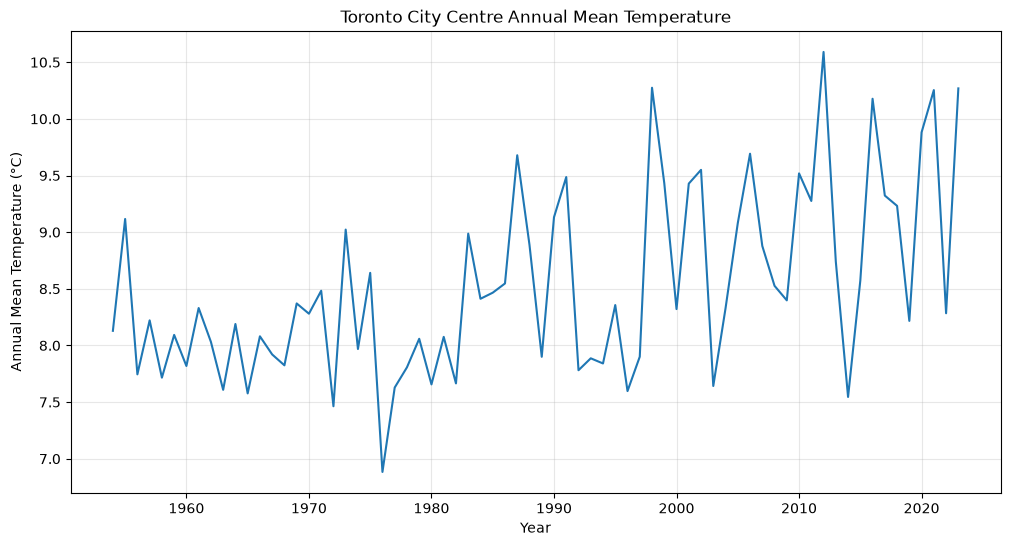

In [59]:
plt.figure(figsize=(12, 6))

plt.plot(
    annual_temp["year"],
    annual_temp["annual_mean_temp"]
)

plt.xlabel("Year")
plt.ylabel("Annual Mean Temperature (°C)")
plt.title("Toronto City Centre Annual Mean Temperature")

plt.grid(alpha=0.3)
plt.show()

In [60]:
annual_temp["rolling_30yr"] = (
    annual_temp["annual_mean_temp"]
    .rolling(window=30, min_periods=25)
    .mean()
)

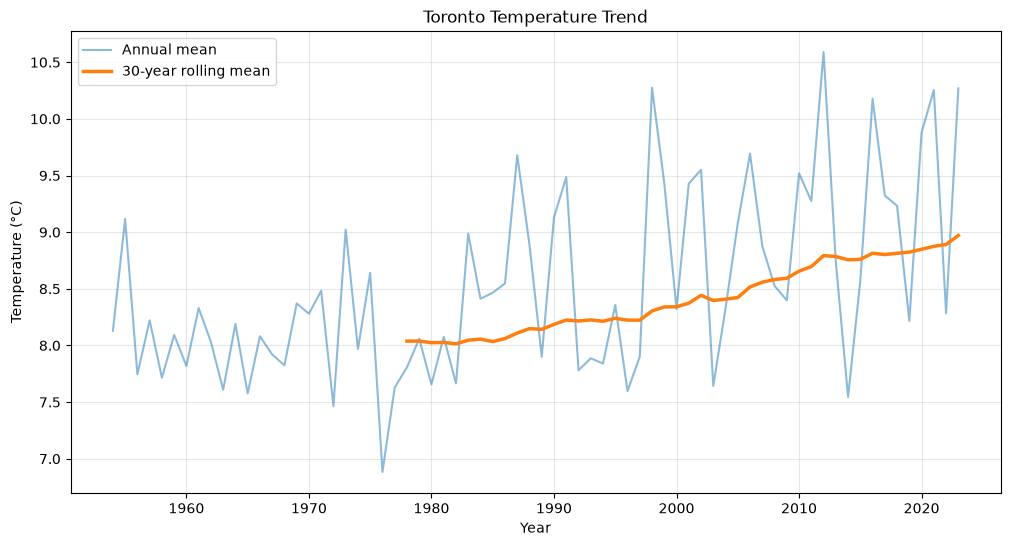

In [61]:
plt.figure(figsize=(12, 6))

plt.plot(
    annual_temp["year"],
    annual_temp["annual_mean_temp"],
    alpha=0.5,
    label="Annual mean"
)

plt.plot(
    annual_temp["year"],
    annual_temp["rolling_30yr"],
    linewidth=2.5,
    label="30-year rolling mean"
)

plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.title("Toronto Temperature Trend")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# temperature anomalies

In [40]:
baseline = annual_temp[
    annual_temp["year"].between(1991, 2020)
]["annual_mean_temp"].mean()

print("1991–2020 baseline:", baseline)

1991–2020 baseline: 8.849216993218814


In [41]:
annual_temp["temp_anomaly"] = (
    annual_temp["annual_mean_temp"] - baseline
)

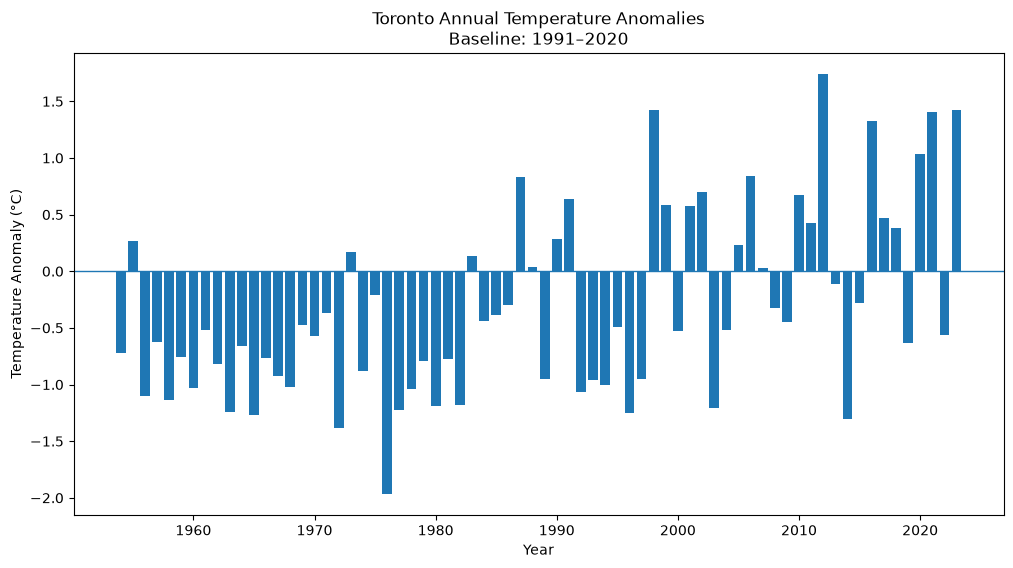

In [42]:
plt.figure(figsize=(12, 6))

plt.bar(
    annual_temp["year"],
    annual_temp["temp_anomaly"]
)

plt.axhline(0, linewidth=1)

plt.xlabel("Year")
plt.ylabel("Temperature Anomaly (°C)")
plt.title("Toronto Annual Temperature Anomalies\nBaseline: 1991–2020")

plt.show()

# warming trend in °C per decade. That gives you a concrete climate result instead of just a visual trend.

In [43]:
from scipy.stats import linregress

trend_data = annual_temp.dropna(
    subset=["annual_mean_temp"]
)

result = linregress(
    trend_data["year"],
    trend_data["annual_mean_temp"]
)

slope_per_year = result.slope
slope_per_decade = slope_per_year * 10

print("Trend per year:", slope_per_year)
print("Trend per decade:", slope_per_decade)
print("p-value:", result.pvalue)
print("R²:", result.rvalue**2)

Trend per year: 0.021761649698468874
Trend per decade: 0.21761649698468874
p-value: 1.518864609283902e-06
R²: 0.29000363784098526


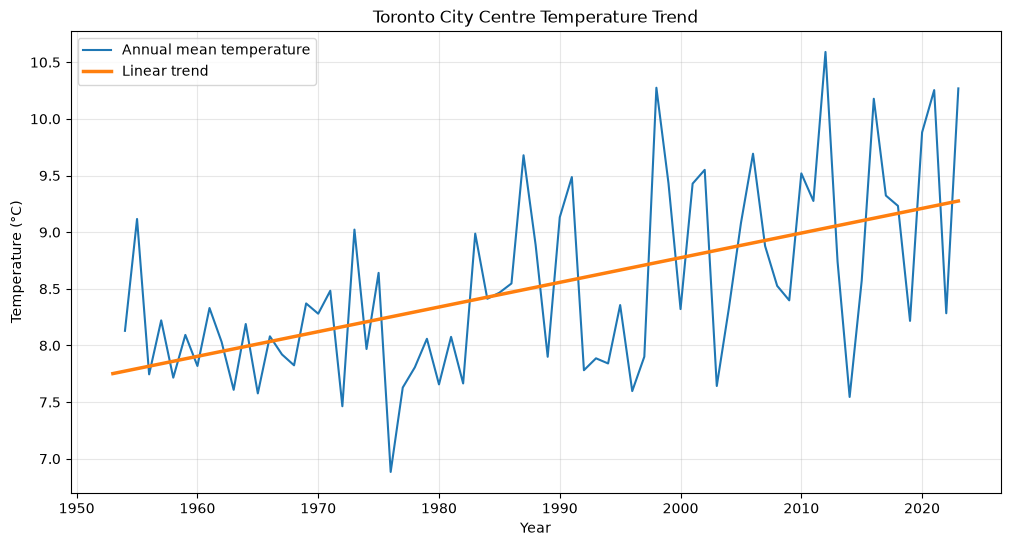

In [44]:
annual_temp["trend_line"] = (
    result.intercept
    + result.slope * annual_temp["year"]
)

plt.figure(figsize=(12, 6))

plt.plot(
    annual_temp["year"],
    annual_temp["annual_mean_temp"],
    label="Annual mean temperature"
)

plt.plot(
    annual_temp["year"],
    annual_temp["trend_line"],
    linewidth=2.5,
    label="Linear trend"
)

plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.title("Toronto City Centre Temperature Trend")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [45]:
from scipy.stats import linregress

# Tmax trend
tmax_data = annual_temp.dropna(subset=["annual_max_temp"])

tmax_result = linregress(
    tmax_data["year"],
    tmax_data["annual_max_temp"]
)

# Tmin trend
tmin_data = annual_temp.dropna(subset=["annual_min_temp"])

tmin_result = linregress(
    tmin_data["year"],
    tmin_data["annual_min_temp"]
)

print("Tmax trend per decade:", tmax_result.slope * 10)
print("Tmax p-value:", tmax_result.pvalue)
print("Tmax R²:", tmax_result.rvalue**2)

print()

print("Tmin trend per decade:", tmin_result.slope * 10)
print("Tmin p-value:", tmin_result.pvalue)
print("Tmin R²:", tmin_result.rvalue**2)

Tmax trend per decade: 0.21949409366109324
Tmax p-value: 1.953414894981985e-06
Tmax R²: 0.2849005723281991

Tmin trend per decade: 0.216133404570403
Tmin p-value: 2.996233199874622e-06
Tmin R²: 0.27614973439889096


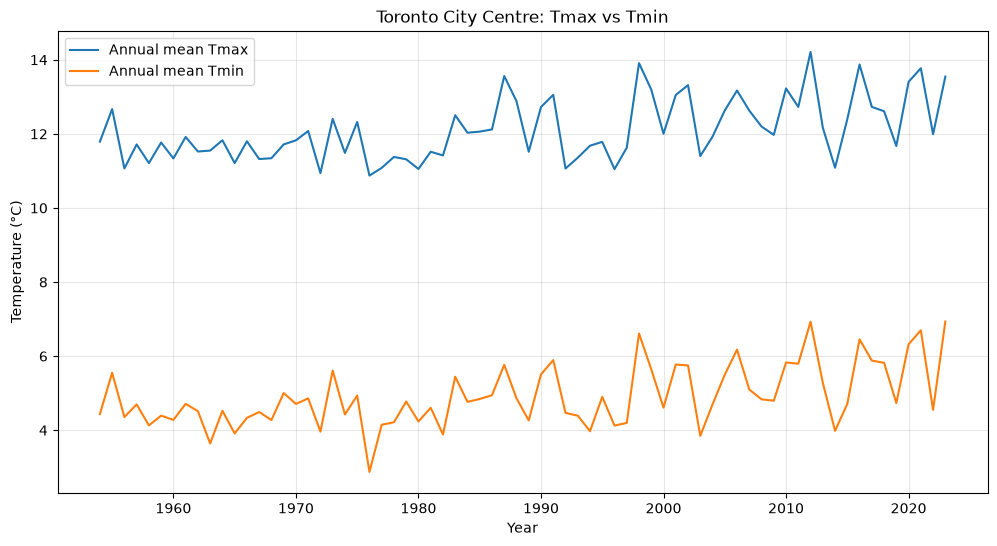

In [46]:
plt.figure(figsize=(12, 6))

plt.plot(
    annual_temp["year"],
    annual_temp["annual_max_temp"],
    label="Annual mean Tmax"
)

plt.plot(
    annual_temp["year"],
    annual_temp["annual_min_temp"],
    label="Annual mean Tmin"
)

plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.title("Toronto City Centre: Tmax vs Tmin")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [47]:
df["time"] = pd.to_datetime(df["time"])
df["year"] = df["time"].dt.year
df["month"] = df["time"].dt.month

def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"

df["season"] = df["month"].apply(get_season)

In [48]:
df["season_year"] = df["year"]

df.loc[
    df["month"] == 12,
    "season_year"
] = df.loc[df["month"] == 12, "year"] + 1

In [49]:
seasonal_temp = (
    df.groupby(["season_year", "season"])
      .agg(
          mean_temp=("tas", "mean"),
          valid_days=("tas", "count")
      )
      .reset_index()
)

In [50]:
expected_days = {
    "Winter": 90,
    "Spring": 92,
    "Summer": 92,
    "Fall": 91
}

seasonal_temp["expected_days"] = seasonal_temp["season"].map(expected_days)

seasonal_temp["coverage_pct"] = (
    seasonal_temp["valid_days"]
    / seasonal_temp["expected_days"]
    * 100
)

seasonal_temp.loc[
    seasonal_temp["coverage_pct"] < 90,
    "mean_temp"
] = np.nan

In [52]:
df["hot_day"] = df["tasmax"] >= 30
df["very_cold_day"] = df["tasmin"] <= -20

In [53]:
extreme_yearly = (
    df.groupby("year")
      .agg(
          hot_days=("hot_day", "sum"),
          very_cold_days=("very_cold_day", "sum")
      )
      .reset_index()
)

display(extreme_yearly.head())

,year,hot_days,very_cold_days
0,1953,6,0
1,1954,2,1
2,1955,6,1
3,1956,1,0
4,1957,0,2


In [54]:
extreme_yearly = extreme_yearly.merge(
    yearly_quality[["year", "usable_for_annual"]],
    on="year",
    how="left"
)

extreme_yearly = extreme_yearly[
    extreme_yearly["usable_for_annual"]
].copy()

In [55]:
from scipy.stats import linregress

hot_result = linregress(
    extreme_yearly["year"],
    extreme_yearly["hot_days"]
)

cold_result = linregress(
    extreme_yearly["year"],
    extreme_yearly["very_cold_days"]
)

print("Hot days trend per decade:",
      hot_result.slope * 10)

print("Hot days p-value:",
      hot_result.pvalue)

print()

print("Very cold days trend per decade:",
      cold_result.slope * 10)

print("Very cold days p-value:",
      cold_result.pvalue)

Hot days trend per decade: 0.24617268830373543
Hot days p-value: 0.39957090272708684

Very cold days trend per decade: -0.07488408713148455
Very cold days p-value: 0.49687352282853176


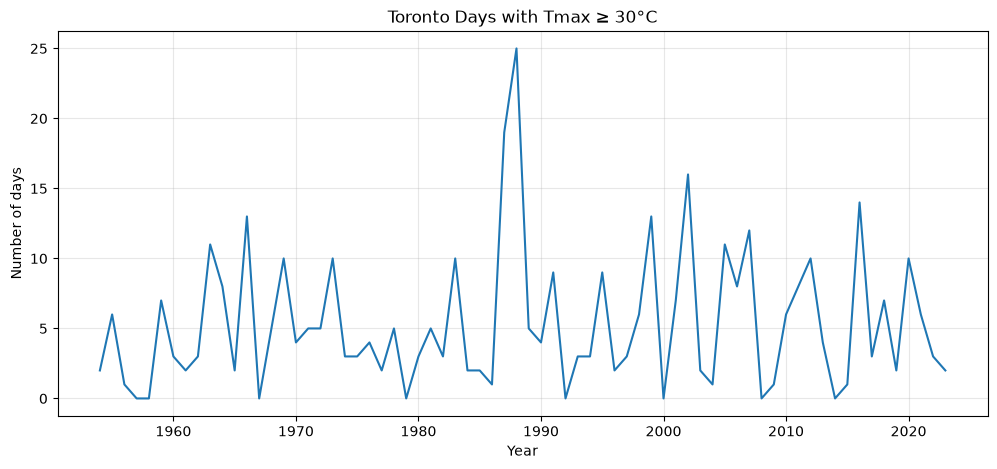

In [56]:
plt.figure(figsize=(12, 5))

plt.plot(
    extreme_yearly["year"],
    extreme_yearly["hot_days"]
)

plt.xlabel("Year")
plt.ylabel("Number of days")
plt.title("Toronto Days with Tmax ≥ 30°C")
plt.grid(alpha=0.3)

plt.show()

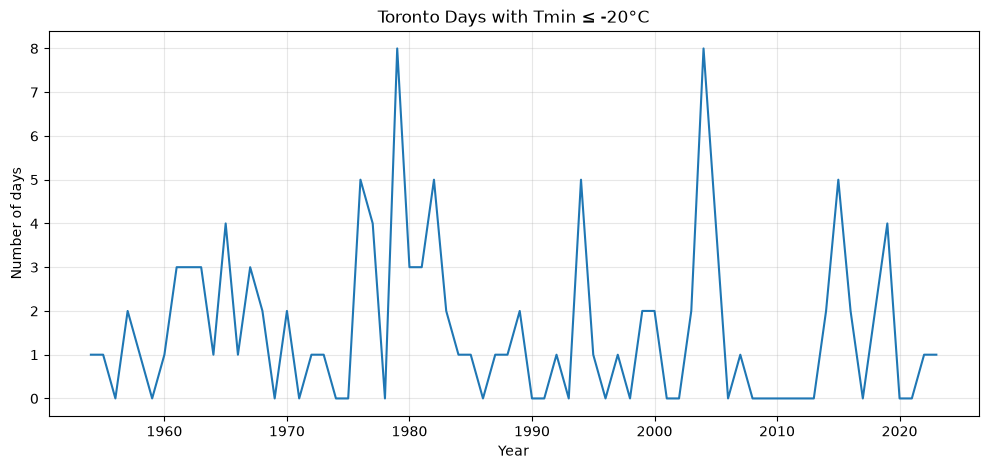

In [57]:
plt.figure(figsize=(12, 5))

plt.plot(
    extreme_yearly["year"],
    extreme_yearly["very_cold_days"]
)

plt.xlabel("Year")
plt.ylabel("Number of days")
plt.title("Toronto Days with Tmin ≤ -20°C")
plt.grid(alpha=0.3)

plt.show()

# Precipitation / snowfall trend

In [77]:
# time
# rain
# snow
# total_precip

# This will not work as sooon as we don't have precepitation data

In [75]:
# precip_df["time"] = pd.to_datetime(precip_df["time"])
# precip_df["year"] = precip_df["time"].dt.year

# annual_precip = (
#     precip_df.groupby("year")
#     .agg(
#         annual_rain=("rain", "sum"),
#         annual_snow=("snow", "sum"),
#         annual_precip=("total_precip", "sum")
#     )
#     .reset_index()
# )

In [76]:
# from scipy.stats import linregress

# for col in ["annual_rain", "annual_snow", "annual_precip"]:
#     temp = annual_precip.dropna(subset=[col])

#     result = linregress(
#         temp["year"],
#         temp[col]
#     )

#     print(
#         col,
#         "trend per decade:",
#         result.slope * 10,
#         "| p-value:",
#         result.pvalue
#     )

# Warmest/coldest years + decade comparison

In [62]:
warmest_years = (
    annual_temp
    .dropna(subset=["annual_mean_temp"])
    .nlargest(5, "annual_mean_temp")
    [["year", "annual_mean_temp"]]
)

display(warmest_years)

,year,annual_mean_temp
59,2012,10.590710
45,1998,10.274795
70,2023,10.269061
68,2021,10.253782
63,2016,10.177596


In [63]:
coldest_years = (
    annual_temp
    .dropna(subset=["annual_mean_temp"])
    .nsmallest(5, "annual_mean_temp")
    [["year", "annual_mean_temp"]]
)

display(coldest_years)

,year,annual_mean_temp
23,1976,6.883607
19,1972,7.463388
61,2014,7.545455
12,1965,7.576712
43,1996,7.597253


In [64]:
early = annual_temp[
    annual_temp["year"].between(1954, 1963)
]["annual_mean_temp"].mean()

recent = annual_temp[
    annual_temp["year"].between(2014, 2023)
]["annual_mean_temp"].mean()

difference = recent - early

print("1954–1963 mean:", early)
print("2014–2023 mean:", recent)
print("Difference:", difference)

1954–1963 mean: 8.08106964840017
2014–2023 mean: 9.175610458078179
Difference: 1.0945408096780085


# Better extreme-temperature analysis

In [66]:
# Tmax >= 30°C
# Tmin <= -20°C

In [67]:
hot_threshold = df["tasmax"].quantile(0.95)
cold_threshold = df["tasmin"].quantile(0.05)

print("95th percentile Tmax:", hot_threshold)
print("5th percentile Tmin:", cold_threshold)

95th percentile Tmax: 27.2
5th percentile Tmin: -11.5


In [68]:
df["extreme_hot"] = df["tasmax"] >= hot_threshold
df["extreme_cold"] = df["tasmin"] <= cold_threshold

In [69]:
extreme_percentile = (
    df.groupby("year")
    .agg(
        extreme_hot_days=("extreme_hot", "sum"),
        extreme_cold_days=("extreme_cold", "sum")
    )
    .reset_index()
)

In [70]:
extreme_percentile = extreme_percentile.merge(
    yearly_quality[
        ["year", "usable_tasmax", "usable_tasmin"]
    ],
    on="year",
    how="left"
)

In [71]:
hot_data = extreme_percentile[
    extreme_percentile["usable_tasmax"]
]

cold_data = extreme_percentile[
    extreme_percentile["usable_tasmin"]
]

hot_result = linregress(
    hot_data["year"],
    hot_data["extreme_hot_days"]
)

cold_result = linregress(
    cold_data["year"],
    cold_data["extreme_cold_days"]
)

print(
    "Extreme hot days trend:",
    hot_result.slope * 10,
    "days/decade"
)

print(
    "Hot p-value:",
    hot_result.pvalue
)

print()

print(
    "Extreme cold days trend:",
    cold_result.slope * 10,
    "days/decade"
)

print(
    "Cold p-value:",
    cold_result.pvalue
)

Extreme hot days trend: 1.1057650249322017 days/decade
Hot p-value: 0.05745601199665205

Extreme cold days trend: -1.017583763450267 days/decade
Cold p-value: 0.051082545617989465


# Change-point / acceleration analysis

In [72]:
before = annual_temp[
    annual_temp["year"] < 1990
].dropna(subset=["annual_mean_temp"])

after = annual_temp[
    annual_temp["year"] >= 1990
].dropna(subset=["annual_mean_temp"])

In [73]:
before_result = linregress(
    before["year"],
    before["annual_mean_temp"]
)

after_result = linregress(
    after["year"],
    after["annual_mean_temp"]
)

print(
    "Before 1990:",
    before_result.slope * 10,
    "°C/decade"
)

print(
    "After 1990:",
    after_result.slope * 10,
    "°C/decade"
)

Before 1990: 0.11354191325778167 °C/decade
After 1990: 0.31224668551990364 °C/decade


In [74]:
break_results = []

for break_year in range(1970, 2001):

    before = annual_temp[
        annual_temp["year"] < break_year
    ].dropna(subset=["annual_mean_temp"])

    after = annual_temp[
        annual_temp["year"] >= break_year
    ].dropna(subset=["annual_mean_temp"])

    if len(before) < 15 or len(after) < 15:
        continue

    r1 = linregress(
        before["year"],
        before["annual_mean_temp"]
    )

    r2 = linregress(
        after["year"],
        after["annual_mean_temp"]
    )

    break_results.append({
        "break_year": break_year,
        "before_trend": r1.slope * 10,
        "after_trend": r2.slope * 10,
        "trend_difference": (
            r2.slope - r1.slope
        ) * 10
    })

break_df = pd.DataFrame(break_results)

display(
    break_df.sort_values(
        "trend_difference",
        ascending=False
    ).head(10)
)

,break_year,before_trend,after_trend,trend_difference
0,1970,-0.204814,0.276217,0.481031
3,1973,-0.125054,0.285406,0.410459
1,1971,-0.125207,0.283770,0.408977
9,1979,-0.115525,0.278605,0.394130
8,1978,-0.105489,0.288222,0.393711
11,1981,-0.120463,0.255972,0.376435
10,1980,-0.100910,0.274717,0.375627
7,1977,-0.070164,0.300647,0.370811
12,1982,-0.104220,0.248146,0.352366
13,1983,-0.118737,0.223176,0.341913


# Annual temperature + linear trend + 30-year rolling mean

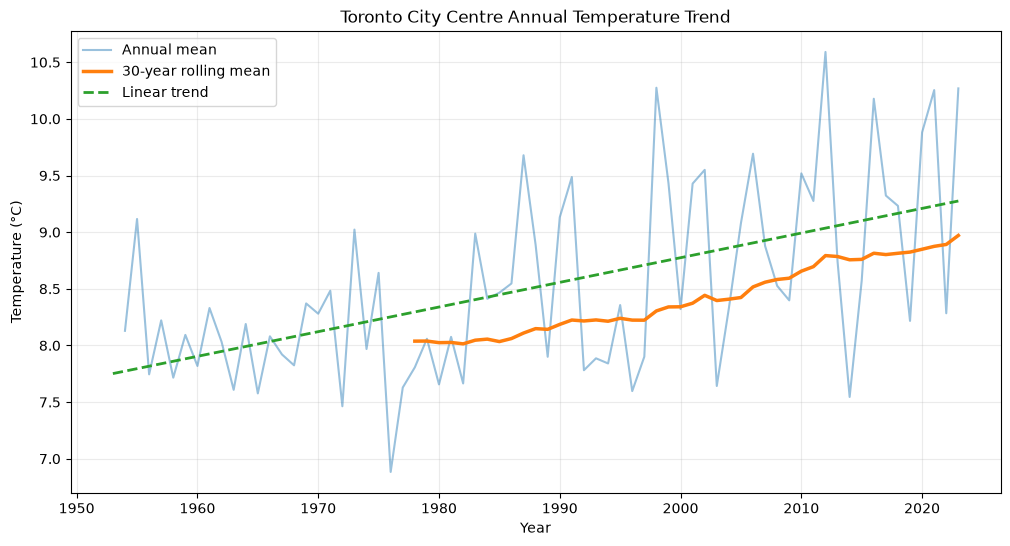

In [79]:
plt.figure(figsize=(12,6))

plt.plot(
    annual_temp["year"],
    annual_temp["annual_mean_temp"],
    alpha=0.45,
    label="Annual mean"
)

plt.plot(
    annual_temp["year"],
    annual_temp["rolling_30yr"],
    linewidth=2.5,
    label="30-year rolling mean"
)

plt.plot(
    annual_temp["year"],
    annual_temp["trend_line"],
    linewidth=2,
    linestyle="--",
    label="Linear trend"
)

plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.title("Toronto City Centre Annual Temperature Trend")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

# Temperature anomaly chart

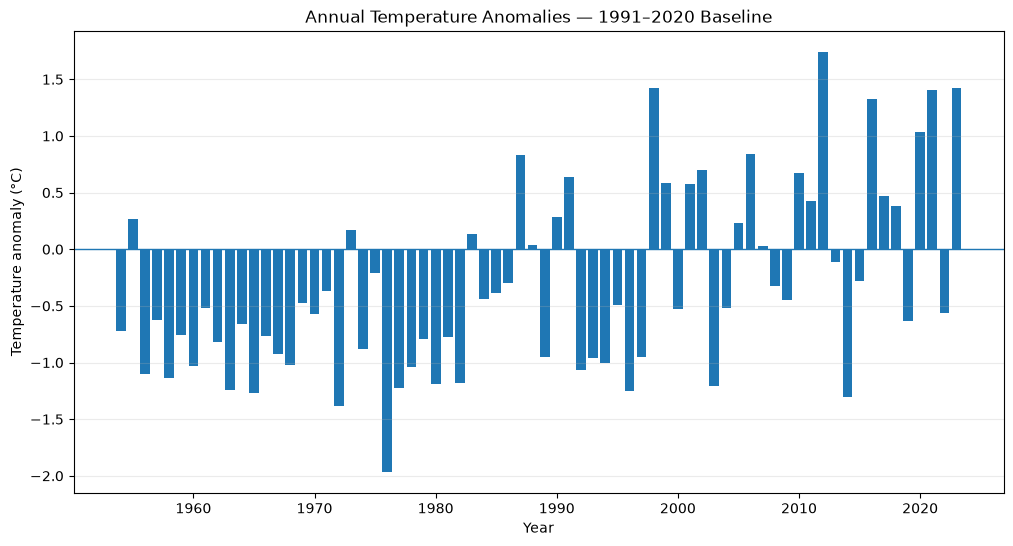

In [80]:
plt.figure(figsize=(12,6))

plt.bar(
    annual_temp["year"],
    annual_temp["temp_anomaly"]
)

plt.axhline(0, linewidth=1)

plt.xlabel("Year")
plt.ylabel("Temperature anomaly (°C)")
plt.title("Annual Temperature Anomalies — 1991–2020 Baseline")

plt.grid(axis="y", alpha=0.25)
plt.show()

# Seasonal warming comparison

In [ ]:
season_trends = pd.DataFrame({
    "season": ["Winter", "Spring", "Summer", "Fall"],
    "trend": [0.301, 0.194, 0.263, 0.128]
})

plt.figure(figsize=(8,5))

plt.bar(
    season_trends["season"],
    season_trends["trend"]
)

plt.ylabel("Temperature trend (°C/decade)")
plt.title("Toronto Warming Rate by Season")

plt.grid(axis="y", alpha=0.25)
plt.show()

# Tmax vs Tmin trend comparison

In [85]:
# Tmax: +0.219°C/decade
# Tmin: +0.216°C/decade

# So your conclusion is:

# Daytime maximum and nighttime minimum temperatures have warmed at nearly identical rates. 
# There is no strong evidence here that one is warming substantially faster than the other.

# Extreme temperatures

In [87]:
# ≥30°C days: +0.25 days/decade
# p = 0.40

# ≤−20°C days: −0.07 days/decade
# p = 0.50
# Although hot-day frequency increased slightly and very-cold-day frequency decreased slightly, neither trend was statistically significant. 
# Therefore, this dataset does not provide strong evidence of a linear change in these specific fixed-threshold extremes.

In [88]:
# Final Part A conclusion

# Once the remaining analyses are complete, your overall conclusion should look approximately like:

# Toronto City Centre shows a clear long-term warming signal from 1954–2023. Annual mean temperature increased by approximately 0.22°C per decade, with statistically significant warming across all seasons. Winter experienced the strongest warming at approximately 0.30°C per decade. Maximum and minimum temperatures increased at similar rates. However, fixed extreme thresholds such as days above 30°C or below −20°C did not show statistically significant linear trends.
# Additional precipitation, percentile-extreme and change-point analyses provide further context on how Toronto's climate has changed.

In [89]:
# By climate-analysis story, I mean the analysis should answer a sequence of connected questions instead of showing random charts.

# A strong story for your Part A is:

# Has Toronto warmed?
# Yes: about +0.22°C per decade from 1954–2023.
# Is that trend statistically meaningful?
# Yes: p < 0.001.
# Is the warming the same in every season?
# No. Winter warmed fastest, fall slowest.
# Are daytime highs and nighttime lows changing differently?
# Not much in your data; Tmax and Tmin trends are very similar.
# Are extreme hot/cold days changing?
# Your fixed thresholds show directionally more hot days and fewer very cold days, but those trends are not statistically significant.
# How does the recent climate compare with the earlier record?
# Use warmest/coldest years and early-vs-recent decade comparison.
# Did the warming rate change over time?
# Use change-point or segmented trend analysis.
# What about precipitation/snowfall?
# Add that once you load the correct precipitation dataset.

# So the story is basically:

# Toronto is warming → the warming differs by season → Tmax and Tmin both rise → some extreme-day metrics are inconclusive → recent decades are warmer → investigate whether the rate changed and whether precipitation/snowfall also shifted.

# Warmest/coldest years + decade comparison

In [90]:
valid_annual = annual_temp.dropna(subset=["annual_mean_temp"])

print("5 Warmest Years")
display(
    valid_annual.nlargest(5, "annual_mean_temp")[
        ["year", "annual_mean_temp"]
    ]
)

print("5 Coldest Years")
display(
    valid_annual.nsmallest(5, "annual_mean_temp")[
        ["year", "annual_mean_temp"]
    ]
)

early_mean = valid_annual[
    valid_annual["year"].between(1954, 1963)
]["annual_mean_temp"].mean()

recent_mean = valid_annual[
    valid_annual["year"].between(2014, 2023)
]["annual_mean_temp"].mean()

print(f"1954–1963: {early_mean:.2f} °C")
print(f"2014–2023: {recent_mean:.2f} °C")
print(f"Difference: {recent_mean - early_mean:+.2f} °C")

5 Warmest Years


,year,annual_mean_temp
59,2012,10.590710
45,1998,10.274795
70,2023,10.269061
68,2021,10.253782
63,2016,10.177596


5 Coldest Years


,year,annual_mean_temp
23,1976,6.883607
19,1972,7.463388
61,2014,7.545455
12,1965,7.576712
43,1996,7.597253


1954–1963: 8.08 °C
2014–2023: 9.18 °C
Difference: +1.09 °C


# Percentile-based extremes

In [91]:
baseline_daily = df[
    df["year"].between(1991, 2020)
]

hot_threshold = baseline_daily["tasmax"].quantile(0.95)
cold_threshold = baseline_daily["tasmin"].quantile(0.05)

print(f"Hot threshold: {hot_threshold:.2f} °C")
print(f"Cold threshold: {cold_threshold:.2f} °C")

df["extreme_hot"] = df["tasmax"] >= hot_threshold
df["extreme_cold"] = df["tasmin"] <= cold_threshold

extremes = (
    df.groupby("year")
      .agg(
          extreme_hot_days=("extreme_hot", "sum"),
          extreme_cold_days=("extreme_cold", "sum")
      )
      .reset_index()
)

extremes = extremes.merge(
    yearly_quality[
        ["year", "usable_tasmax", "usable_tasmin"]
    ],
    on="year"
)

hot = extremes[extremes["usable_tasmax"]]
cold = extremes[extremes["usable_tasmin"]]

hot_result = linregress(
    hot["year"],
    hot["extreme_hot_days"]
)

cold_result = linregress(
    cold["year"],
    cold["extreme_cold_days"]
)

print(
    f"Extreme hot trend: {hot_result.slope*10:.3f} days/decade "
    f"| p={hot_result.pvalue:.4g}"
)

print(
    f"Extreme cold trend: {cold_result.slope*10:.3f} days/decade "
    f"| p={cold_result.pvalue:.4g}"
)

Hot threshold: 27.50 °C
Cold threshold: -11.10 °C
Extreme hot trend: 1.355 days/decade | p=0.01603
Extreme cold trend: -1.327 days/decade | p=0.01313


# Change-point / acceleration

In [92]:
break_results = []

data = annual_temp.dropna(
    subset=["annual_mean_temp"]
).copy()

for break_year in range(1970, 2001):

    before = data[data["year"] < break_year]
    after = data[data["year"] >= break_year]

    if len(before) < 15 or len(after) < 15:
        continue

    before_result = linregress(
        before["year"],
        before["annual_mean_temp"]
    )

    after_result = linregress(
        after["year"],
        after["annual_mean_temp"]
    )

    break_results.append({
        "break_year": break_year,
        "before_C_decade": before_result.slope * 10,
        "after_C_decade": after_result.slope * 10,
        "difference": (
            after_result.slope -
            before_result.slope
        ) * 10
    })

break_df = pd.DataFrame(break_results)

display(
    break_df.sort_values(
        "difference",
        ascending=False
    ).head(10)
)

,break_year,before_C_decade,after_C_decade,difference
0,1970,-0.204814,0.276217,0.481031
3,1973,-0.125054,0.285406,0.410459
1,1971,-0.125207,0.283770,0.408977
9,1979,-0.115525,0.278605,0.394130
8,1978,-0.105489,0.288222,0.393711
11,1981,-0.120463,0.255972,0.376435
10,1980,-0.100910,0.274717,0.375627
7,1977,-0.070164,0.300647,0.370811
12,1982,-0.104220,0.248146,0.352366
13,1983,-0.118737,0.223176,0.341913


# Precipitation + snowfall

In [93]:
# Don't run this yet.

# Your current AHCCD dataset contains temperature only. We need to download Toronto precipitation/snowfall observations first, then analyze:

# annual precipitation
# rainfall
# snowfall
# seasonal precipitation
# trends in mm/decade or cm/decade
# significance and variability

# segmented regression

In [94]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

data = (
    annual_temp
    .dropna(subset=["annual_mean_temp"])
    [["year", "annual_mean_temp"]]
    .copy()
)

# Center year for numerical stability
data["year_c"] = data["year"] - data["year"].mean()

results = []

for break_year in range(1970, 2001):

    # Hinge term: 0 before breakpoint,
    # then increases after breakpoint
    data["post_break"] = np.maximum(
        0,
        data["year"] - break_year
    )

    X = sm.add_constant(
        data[["year_c", "post_break"]]
    )

    model = sm.OLS(
        data["annual_mean_temp"],
        X
    ).fit()

    results.append({
        "break_year": break_year,
        "aic": model.aic,
        "bic": model.bic,
        "post_break_coef": model.params["post_break"],
        "post_break_pvalue": model.pvalues["post_break"]
    })

seg_results = pd.DataFrame(results)

display(
    seg_results.sort_values("aic").head(10)
)

,break_year,aic,bic,post_break_coef,post_break_pvalue
6,1976,148.995962,155.741447,0.035845,0.076718
7,1977,149.029936,155.775422,0.034495,0.078253
8,1978,149.140746,155.886232,0.032919,0.083494
5,1975,149.165696,155.911182,0.036246,0.084725
4,1974,149.261505,156.006991,0.037187,0.089641
9,1979,149.296395,156.041881,0.031268,0.091507
2,1972,149.366996,156.112482,0.040175,0.095413
3,1973,149.389566,156.135052,0.038087,0.096700
1,1971,149.458124,156.203610,0.041775,0.100726
10,1980,149.460245,156.205731,0.029709,0.100853


In [95]:
best_break = int(
    seg_results.loc[
        seg_results["aic"].idxmin(),
        "break_year"
    ]
)

print("Best breakpoint:", best_break)

Best breakpoint: 1976


In [96]:
data["post_break"] = np.maximum(
    0,
    data["year"] - best_break
)

X = sm.add_constant(
    data[["year_c", "post_break"]]
)

seg_model = sm.OLS(
    data["annual_mean_temp"],
    X
).fit()

print(seg_model.summary())

                            OLS Regression Results                            
Dep. Variable:       annual_mean_temp   R-squared:                       0.323
Model:                            OLS   Adj. R-squared:                  0.302
Method:                 Least Squares   F-statistic:                     15.96
Date:                Sat, 12 Sep 2026   Prob (F-statistic):           2.15e-06
Time:                        20:09:55   Log-Likelihood:                -71.498
No. Observations:                  70   AIC:                             149.0
Df Residuals:                      67   BIC:                             155.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.9467      0.332     23.964      0.0

In [97]:
before_slope = seg_model.params["year_c"]

after_slope = (
    seg_model.params["year_c"]
    + seg_model.params["post_break"]
)

print(
    f"Before {best_break}: "
    f"{before_slope * 10:.3f} °C/decade"
)

print(
    f"After {best_break}: "
    f"{after_slope * 10:.3f} °C/decade"
)

print(
    "Slope-change p-value:",
    seg_model.pvalues["post_break"]
)

Before 1976: -0.054 °C/decade
After 1976: 0.305 °C/decade
Slope-change p-value: 0.07671751817716968
